In [20]:
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# transform
transform = v2.Compose([
    v2.ToImage(),
    v2.RandomCrop(32, padding= 4),
    v2.RandomHorizontalFlip(),
    v2.ToDtype(torch.float32, scale = True),
    v2.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])

#dataset

train_dataset = torchvision.datasets.CIFAR10(root = "./data", download = True,train = True, transform = transform)
test_dataset = torchvision.datasets.CIFAR10(root="./data", download = True, train = False, transform = transform)
# data loader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, pin_memory= torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False, pin_memory= torch.cuda.is_available())

In [21]:
from torch.nn.modules.linear import Linear
from torch.nn.modules.flatten import Flatten
class Convolution(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(3,6,3,1,1),
        nn.BatchNorm2d(6),
        nn.ReLU(),

        nn.Conv2d(6,12,3,1,1),
        nn.BatchNorm2d(12),
        nn.ReLU(),

        nn.MaxPool2d(2,2),

        nn.Conv2d(12,24,3,1,1),
        nn.BatchNorm2d(24),
        nn.ReLU(),

        nn.Conv2d(24,48,3,1,1),
        nn.BatchNorm2d(48),
        nn.ReLU(),

        nn.MaxPool2d(2,2),

        nn.Flatten(),

        nn.Linear(48*8*8, 600),
        nn.ReLU(),

        nn.Linear(600,120),
        nn.ReLU(),

        nn.Linear(120,24),
        nn.ReLU(),

        nn.Linear(24,10)
    )

  def forward(self,X):
    return self.model(X)

model = Convolution()
model = model.to(device)
model

Convolution(
  (model): Sequential(
    (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_features=3072

In [22]:
lr = 0.001
epochs = 5
optimizer = optim.Adam(model.parameters(), lr = lr)
loss_fn = nn.CrossEntropyLoss()

Epoch : [1 / 5] : 0.8107670011
Epoch : [2 / 5] : 0.7638254358
Epoch : [3 / 5] : 0.7355928920
Epoch : [4 / 5] : 0.7081789361
Epoch : [5 / 5] : 0.6902079373


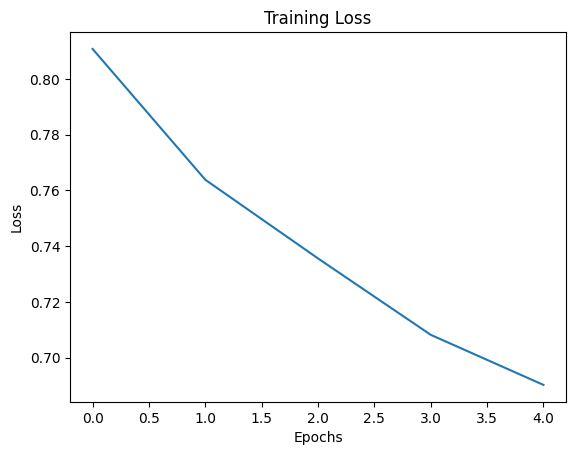

In [25]:
train_losses = []
for epoch in range(epochs):
  model.train()
  total_epoch_loss = 0;
  for batch_X, batch_y in train_loader:
    batch_X = batch_X.to(device)
    batch_y = batch_y.to(device)

    y_pred = model(batch_X)
    loss = loss_fn(y_pred, batch_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss +=loss.item()
  average_epoch_loss = total_epoch_loss/len(train_loader)
  train_losses.append(average_epoch_loss)
  print(f"Epoch : [{epoch + 1 } / {epochs}] : {average_epoch_loss:.10f}")
plt.plot([t1 for t1 in train_losses])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [26]:
correct = 0
total_labels = len(test_dataset)
model.eval()

with torch.no_grad():
  for batch_X, batch_y in test_loader:
    batch_correct_preds = 0
    batch_X = batch_X.to(device)
    batch_y  = batch_y.to(device)
    y_pred = model(batch_X)
    predicted_labels = torch.argmax(y_pred, dim =1)
    batch_correct_preds += (predicted_labels == batch_y).sum().item()
    correct += batch_correct_preds

print(correct)
acc = correct/ total_labels
print(f"The accuracy of the currrent model is : {acc*100:.10f}")



7530
The accuracy of the currrent model is : 75.3000000000
